In [2]:
import numpy as np
import geopandas as gpd
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'
TEST_YEAR = '2022'
TEST_MONTH = '8'
NUTS2_EL = 'θεσσαλιας'

In [4]:
trained_model = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Trained_Model.pkl', 'rb'))
scaler = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Scaler.pkl', 'rb'))
imputer = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Imputer.pkl', 'rb'))
feature_names = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Feature_List.pkl', 'rb'))

In [5]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'

test_file = f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_2010_2023.csv'
data_test = read_data(test_file)
data_test.reset_index(drop = True, inplace = True)
print(data_test.shape)

(504, 112)


In [6]:
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL611,2010,1,21.720538,39.507246,0.344330,0.131772,-0.164562,-0.131772,0.351663,0.138953,-0.161584,-0.138953,0.072157,0.073429,0.095126,0.073429,10.324867,4.699393,7.541364,13.255044,13.255044,3.412974,1.761039,0.200398,1.498356,1.498356,6.868921,3.230216,3.870881,7.395288,7.395288,1.743648,14.674717,9.513972,36.701100,124.217848,292.411665,2058.948979,738.424528,23.820146,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,10352.0,10375.0,0
1,EL612,2010,1,22.407574,39.702044,0.263468,-0.034510,-0.273834,0.034510,0.249646,-0.036767,-0.264302,0.036767,0.058782,0.058005,0.042991,0.058005,12.333341,6.793895,10.575814,16.242166,16.242166,4.519342,1.699212,0.966283,2.243861,2.243861,8.426342,4.246554,5.771048,9.243013,9.243013,2.268996,16.713441,9.078019,35.835411,107.246464,280.483500,1454.989694,769.064516,24.808533,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,31,36,30,12,12,1,6,7,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,23291.0,94577.0,25594.0,143462.0,22117.0,93495.0,30638.0,146250.0,5066.81,7604.0,8362.0,0
2,EL613,2010,1,22.862978,39.279998,0.322976,0.136636,-0.129853,-0.136636,0.309199,0.148988,-0.100460,-0.148988,0.043004,0.048798,0.061535,0.048798,12.159471,6.264925,9.527607,14.859624,14.859624,6.342837,2.651805,1.864013,3.901596,3.901596,9.251154,4.458365,5.695810,9.380610,9.380610,3.658866,16.772062,9.868127,44.910923,82.850549,304.801321,1435.288760,517.865979,16.705354,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,31,20,30,12,12,1,6,1,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0

In [7]:
data_test = data_test[data_test['year'] == 2022]
data_test.reset_index(drop=True, inplace=True)
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL611,2022,1,21.720538,39.507246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.110534,11.777889,14.830523,14.830523,NaN,0.956701,4.295250,2.420615,2.420615,NaN,4.033617,8.036569,8.625569,8.625569,1.383803,15.082256,8.268830,40.605375,41.017536,256.308584,1786.504218,1429.713836,46.119801,17.000000,20.000000,47.619048,818.535277,40.0,-2.0,42.0,9.000000,24.000000,26.500000,7.333333,1780.0,478.0,34.0,88.087640,923.0,136.0,138.0,873.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,14610.0,68583.0,30631.0,113824.0,13766.0,66633.0,35877.0,116276.0,2452.45,6070.0,6292.0,0
1,EL612,2022,1,22.407574,39.702044,0.371396,0.136088,-0.289441,-0.136088,0.347480,0.157929,-0.281058,-0.157929,0.064474,0.064787,0.056388,0.064787,NaN,9.367512,13.576347,17.085512,17.085512,NaN,1.051956,4.355890,3.099344,3.099344,NaN,5.209734,8.966118,10.092428,10.092428,2.131160,13.539947,4.101621,22.639931,23.328974,127.150243,1320.719551,2226.720430,71.829691,18.333333,22.500000,46.875000,876.805497,44.0,-4.0,48.0,10.000000,26.000000,28.333333,7.333333,1316.0,305.0,30.0,74.185825,544.0,158.0,174.0,489.0,31,36,30,12,12,1,6,7,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,21009.0,84294.0,29708.0,135011.0,19676.0,88295.0,35522.0,143493.0,3864.93,2621.0,2977.0,0
2,EL613,2022,1,22.862978,39.279998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.874270,13.040574,15.005544,15.005544,NaN,2.757024,5.936517,4.833871,4.833871,NaN,6.315647,9.488546,9.919707,9.919707,2.760552,16.117242,3.046598,26.012188,30.370800,94.444031,1160.064517,592.329897,19.107416,17.666667,19.333333,46.031746,784.895284,41.0,-1.0,42.0,14.833333,24.833333,27.500000,8.500000,1154.0,207.0,22.0,65.458301,490.0,135.0,157.0,318.0,31,20,30,12,12,1,1,1,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.0,1.0,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.58324

In [8]:
data_test = encode_cyclical(data_test, 'month', 12)

In [9]:
len(data_test.NUTS3_ID.unique())

3

In [10]:
data_test = data_test.query(f'month == {TEST_MONTH}')
data_test.reset_index(drop=True, inplace=True)

In [11]:
data_test.head(10)

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases,month_sin,month_cos
0,EL611,2022,8,21.720538,39.507246,0.546171,0.153494,-0.482367,-0.153494,0.539662,0.150667,-0.476151,-0.150667,0.068722,0.067846,0.047963,0.067846,31.715249,7.914135,11.216229,11.015336,11.015336,19.513252,0.694309,1.202068,0.426461,0.426461,25.614250,4.304222,6.225693,5.720898,5.720898,16.689937,36.780377,1.143659,0.739212,0.794543,17.632596,737.274370,1102.323899,35.558835,17.000000,20.000000,47.619048,818.535277,40.0,-2.0,42.0,9.000000,24.000000,26.500000,7.333333,1780.0,478.0,34.0,88.087640,923.0,136.0,138.0,873.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,14610.0,68583.0,30631.0,113824.0,13766.0,66633.0,35877.0,116276.0,2452.45,6070.0,6292.0,2,-0.866025,-0.5
1,EL612,2022,8,22.407574,39.702044,0.398083,0.017228,-0.387692,-0.017228,0.393947,0.018482,-0.383556,-0.018482,0.064722,0.065416,0.043508,0.065416,36.689750,9.664822,13.428722,14.094715,14.094715,20.313101,0.401932,1.381262,0.514417,0.514417,28.501426,5.033377,7.404992,7.304566,7.304566,17.126846,40.606631,2.496740,1.468117,1.468117,69.427854,768.932408,1387.215054,44.748873,18.333333,22.500000,46.875000,876.805497,44.0,-4.0,48.0,10.000000,26.000000,28.333333,7.333333,1316.0,305.0,30.0,74.185825,544.0,158.0,174.0,489.0,31,36,30,12,12,1,6,7,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,21009.0,84294.0,29708.0,135011.0,19676.0,88295.0,35522.0,143493.0,3864.93,2621.0,2977.0,6,-0.866025,-0.5
2,EL613,2022,8,22.862978,39.279998,0.484273,0.141463,-0.430132,-0.141463,0.479020,0.132129,-0.429493,-0.132129,0.058591,0.059670,0.040256,0.059670,33.343661,9.201639,11.725066,11.099957,11.099957,20.584366,3.211802,3.562850,2.340196,2.340196,26.964014,6.206721,7.643958,6.720076,6.720076,17.615773,37.976392,1.824213,0.027673,0.027673,53.927196,748.588709,768.969072,24.805454,17.666667,19.333333,46.031746,784.895284,41.0,-1.0,42.0,14.833333,24.833333,27.500000,8.500000,1154.0,207.0,22.0,65.458301,490.0,135.0,157.0,318.0,31,20,30,12,12,1,1,1,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.

In [12]:
features = data_test.loc[:, data_test.columns.isin(feature_names)].columns
print(features.to_list())

print(f"Total Features Used: {len(features)}")

['ndvi', 'ndmi', 'ndwi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_gt65', 'mio_eur', 'l_total', 'unl_total', 'month_sin', 'month_cos']
Total Features Used: 64


In [13]:
X_test = data_test.loc[:, data_test.columns.isin(feature_names)]
y_test = data_test['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.fit_transform(X_test_scaled)

y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

In [14]:
results = pd.concat([data_test.iloc[:, :5], pd.Series(y_test_prob, name='score')], axis=1)

In [15]:
results.sort_values(by='score', ascending=False).head(5)

,NUTS3_ID,year,month,x,y,score
1,EL612,2022,8,22.407574,39.702044,0.973697
0,EL611,2022,8,21.720538,39.507246,0.762795
2,EL613,2022,8,22.862978,39.279998,0.132804


In [16]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"

greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_Whole.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [17]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_nuts2 CRS: EPSG:4326
greece_nuts3 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326


In [18]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL61,Θεσσαλία,"MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


In [19]:
greece_nuts3_gdf.head()

,NUTS3_ID,NUTS3_NAME,geometry
0,EL611,"Καρδίτσα, Τρίκαλα","POLYGON ((21.91769 39.85205, 21.95557 39.84969..."
1,EL612,Λάρισα,"POLYGON ((22.66458 39.97476, 22.70870 39.95235..."
2,EL613,"Μαγνησία, Σποράδες","MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


In [20]:
greece_lau1.head()

,NAME,geometry
0,Αγιάς,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
1,Αλοννήσου,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
2,Αλμυρού,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
3,Αργιθέας,"POLYGON ((21.43616 39.41522, 21.43830 39.41454..."
4,Βόλου,"POLYGON ((22.97208 39.45655, 22.97346 39.45643..."


In [21]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,SMOKOVO RESERVOIR,9917521.0,57610.200,"POLYGON ((22.15620 39.12133, 22.15606 39.12153...",0
1,KARLAS RESERVOIR,34925588.0,29704.895,"POLYGON ((22.78083 39.49649, 22.78114 39.49670...",1
2,TAVROPOS RESERVOIR,23560746.0,85317.960,"POLYGON ((21.69880 39.34183, 21.69943 39.34191...",2


In [22]:
results = pd.merge(results, greece_nuts3_gdf, on='NUTS3_ID', how='left')
results = gpd.GeoDataFrame(results, geometry='geometry')
results['x'] = results['x'].round(4)
results['y'] = results['y'].round(4)
results.rename(columns={'score': 'risk_score'}, inplace=True)
results['risk_score'] = results['risk_score'].round(6)

In [23]:
type(results)

geopandas.geodataframe.GeoDataFrame

In [24]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

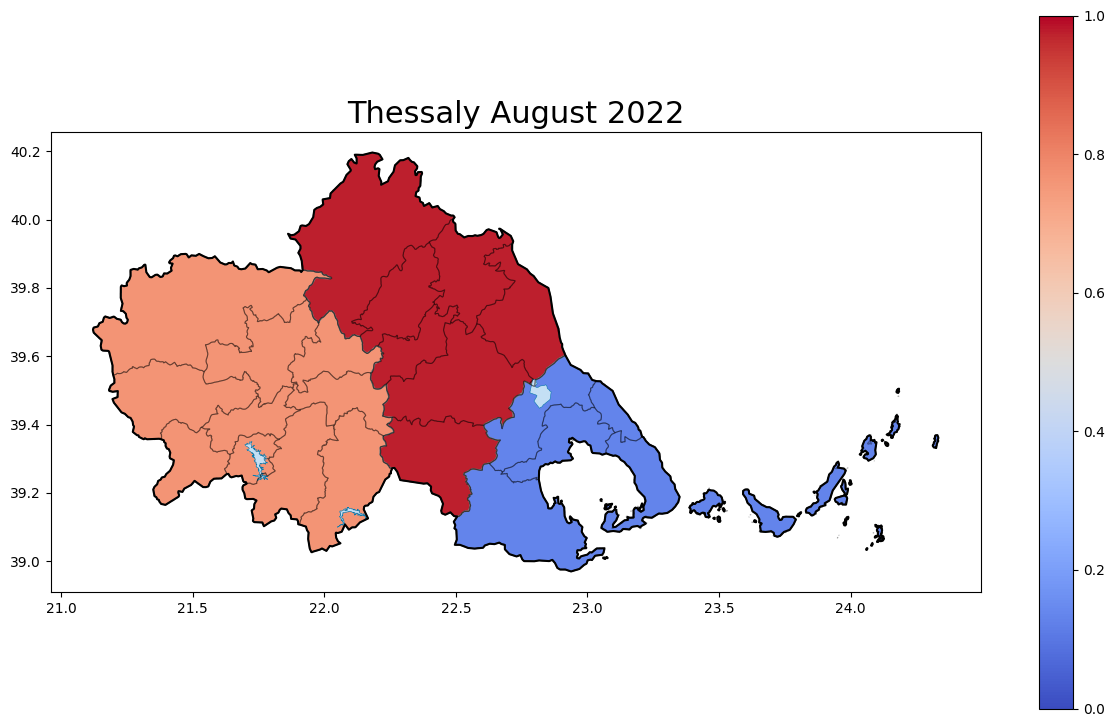

In [25]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)


plt.title(f'{NUTS2} {month_dict.get(results.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [26]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, #greece_lau1, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, fig_title = '[EL61]Thessaly - August 2022',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=650, fig_width=1000, size_f5=6.5)

fig.show()

In [27]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL611,2022,8,21.7205,39.5072,0.762795,"Καρδίτσα, Τρίκαλα","POLYGON ((21.91769 39.85205, 21.95557 39.84969..."
1,EL612,2022,8,22.4076,39.7020,0.973697,Λάρισα,"POLYGON ((22.66458 39.97476, 22.70870 39.95235..."
2,EL613,2022,8,22.8630,39.2800,0.132804,"Μαγνησία, Σποράδες","MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


In [28]:
results[['NUTS3_ID', 'NUTS3_NAME', 'year', 'month', 'risk_score']]

,NUTS3_ID,NUTS3_NAME,year,month,risk_score
0,EL611,"Καρδίτσα, Τρίκαλα",2022,8,0.762795
1,EL612,Λάρισα,2022,8,0.973697
2,EL613,"Μαγνησία, Σποράδες",2022,8,0.132804


In [29]:
#results.to_file(f'../../../data/{NUTS2}/predictions/GR_{NUTS2}_NUTS3_Predictions_June_2024.shp', encoding = 'utf-8')